# De la brecha a la oportunidad

Descomposición del share en efecto de plaza, efecto de familia y residuo, y valoración de lo que vale cerrarlo.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd

from src import benchmark, brechas, data_io, robustez, viz
from src import config as cfg

pd.set_option("display.width", 200)
viz.aplicar_estilo()

panel = data_io.construir_panel()
plaza = data_io.panel_plaza(panel)
bench = benchmark.generar(plaza)

ventana = brechas.ventana(bench, 12)
material = brechas.filtrar_material(ventana)
d = brechas.descomponer(material)

res_mens = brechas.residuos_mensuales(bench, 24)
persist = brechas.persistencia(res_mens)
elast = brechas.elasticidad_promo(panel)
r = brechas.ranking(d, persist, elast)
prioritarias = r[r.prioritaria].sort_values("oport_contribucion", ascending=False)

print(f"R2 ponderado: {d.attrs['r2']:.3f} · {len(material)} celdas materiales de {len(ventana)}")

R2 ponderado: 0.987 · 180 celdas materiales de 699


## Lo que la plaza y la familia no explican

El residuo del modelo aditivo: cuánto rinde cada celda por encima o por debajo de lo que predicen su plaza y su familia.

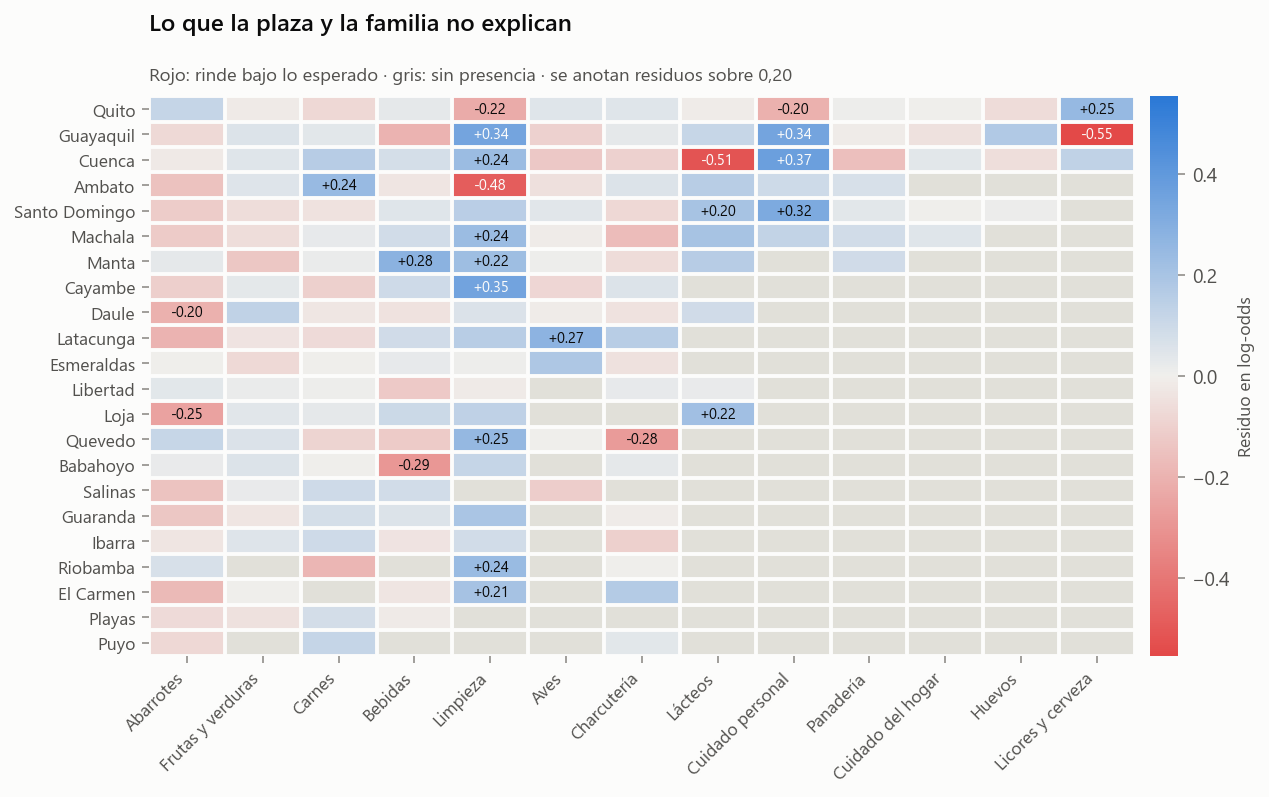

In [2]:
#| label: fig-mapa-brechas
#| fig-cap: "Residuo en log-odds por plaza y familia."
fig = viz.fig_mapa_brechas(d)

## Persistencia

Una brecha que aparece un trimestre y se va es ruido. La que sobrevive dos años es una posición competitiva.

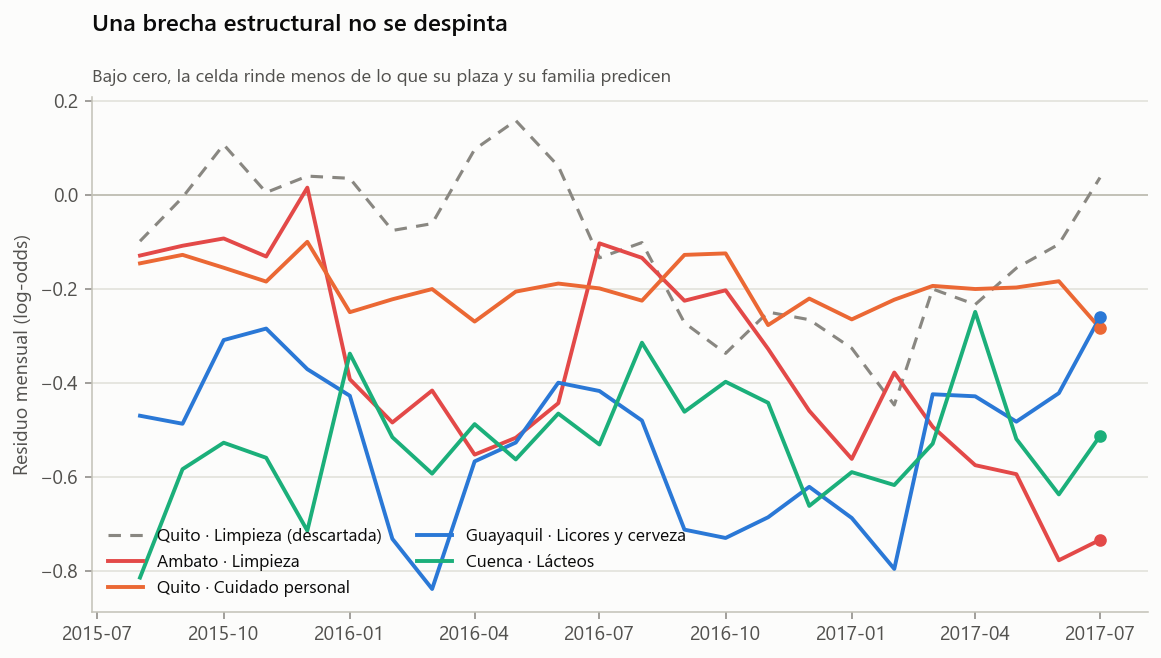

In [3]:
#| label: fig-persistencia
#| fig-cap: "Residuo mensual de las celdas prioritarias y de una celda descartada por inestable."
celdas = list(zip(prioritarias.city, prioritarias.family))[:4]
sobrantes = r[(r.material) & (~r.prioritaria) & (r.oport_contribucion > 0)]
peor = sobrantes.sort_values("oport_contribucion", ascending=False).iloc[0]
fig = viz.fig_persistencia(res_mens, celdas, (peor.city, peor.family))

## El embudo

De toda la brecha contable, cuánta sobrevive a cada filtro.

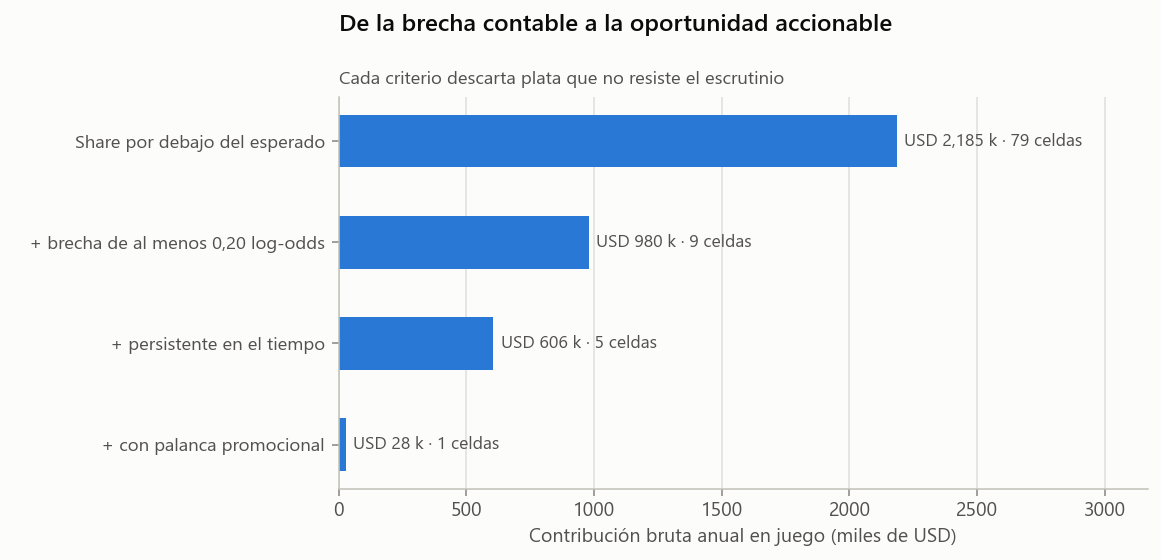

In [4]:
#| label: fig-embudo
#| fig-cap: "Contribución en juego según el criterio aplicado."
fig = viz.fig_embudo(brechas.embudo(r))

## ¿Sirve la promoción?

Respuesta del volumen a los ítems en promoción, con efectos fijos de tienda y de mes.

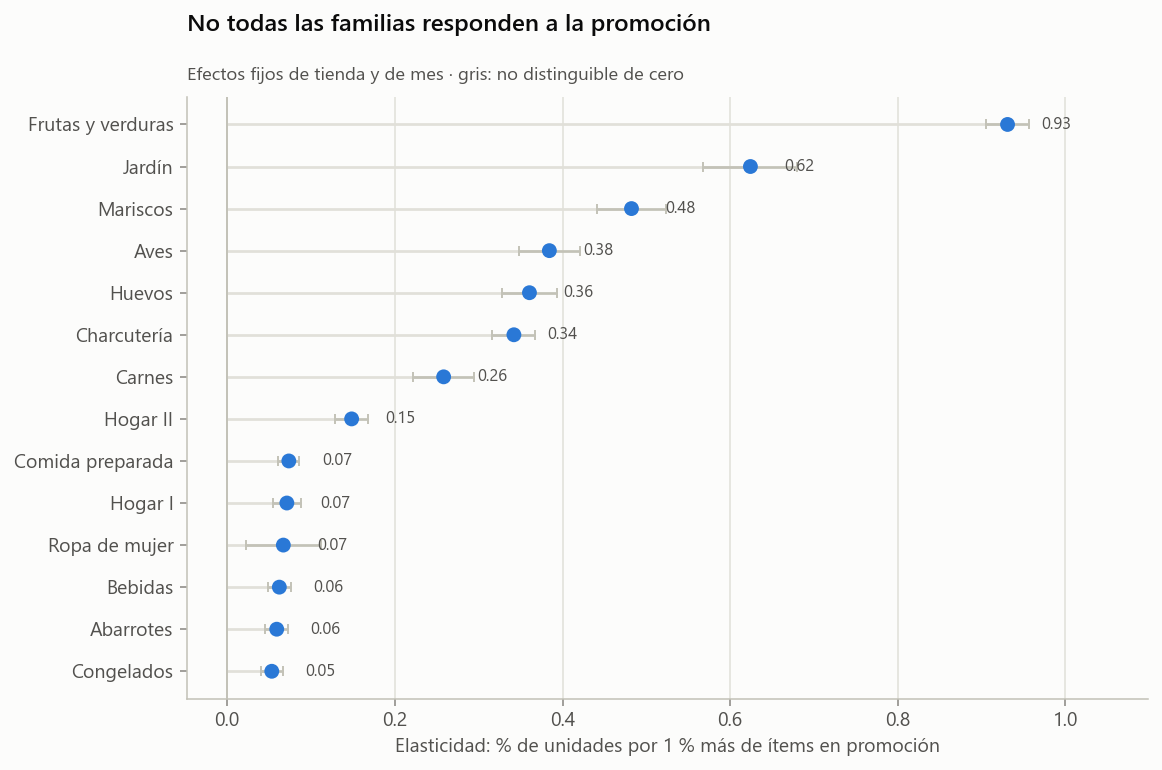

In [5]:
#| label: fig-elasticidad
#| fig-cap: "Elasticidad promocional por familia."
fig = viz.fig_elasticidad(elast, familias=d.family.unique())

## Qué vale cada oportunidad

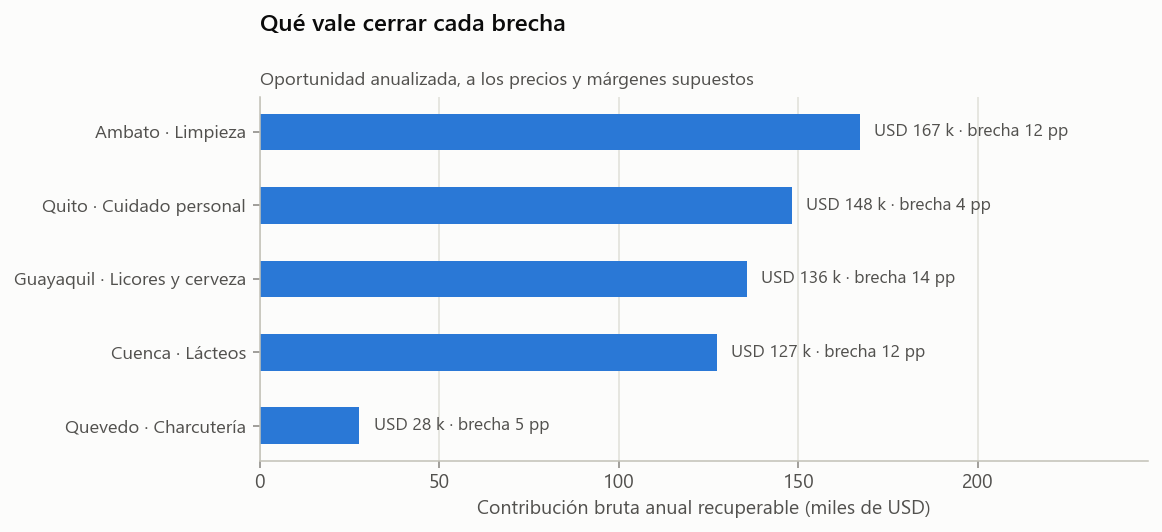

In [6]:
#| label: fig-valor
#| fig-cap: "Contribución bruta anual recuperable por celda."
fig = viz.fig_valor(prioritarias)

In [7]:
#| label: tbl-prioritarias
#| tbl-cap: "Oportunidades prioritarias."
cols = ["city", "family", "share", "share_esperado", "brecha_pp",
        "oport_ingreso", "oport_contribucion", "t_ajustado", "elasticidad"]
prioritarias[cols].round(3)

,city,family,share,share_esperado,brecha_pp,oport_ingreso,oport_contribucion,t_ajustado,elasticidad
2,Ambato,CLEANING,0.374,0.491,11.760,643054.845,167194.260,-2.952,0.027
153,Quito,PERSONAL CARE,0.747,0.783,3.649,463297.264,148255.125,-16.884,0.019
71,Guayaquil,"LIQUOR,WINE,BEER",0.455,0.592,13.714,484694.814,135714.548,-7.889,0.050
26,Cuenca,DAIRY,0.349,0.472,12.303,578492.746,127268.404,-19.467,0.033
133,Quevedo,DELI,0.221,0.272,5.128,79253.192,27738.617,-3.980,0.342
